# Дискретно-событийная модель SEIR

Добавим латентный период: заразившийся человек сначала попадает
в группу $E$ и ещё не заражает других, а через случайное время
со средним $1/\sigma$ становится больным. Сравним эту модель с SIR.

## Активация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"
@isdefined(SIRDES) || include(srcdir("sir_model.jl"))
using .SIRDES
using Random, Plots, DataFrames, CSV

script_name = "sir_des_seir"
mkpath(plotsdir())
mkpath(datadir())

"/home/iaberezhnoy/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation-modeling/labs/lab08/project/data"

## Параметры модели

Параметры заражения те же, латентный период в среднем длится
$1/\sigma = 2$.

In [2]:
tmax = 60.0
u0 = [990, 10, 0]
p = [0.05, 10.0, 0.25]
σ = 0.5

0.5

## Модель SIR

In [3]:
Random.seed!(1234)
m_sir = MakeXModel(u0, p)
activate_x(m_sir)
run_x(m_sir, tmax)
df_sir = out_x(m_sir)

Row,t,S,E,I,R,N
,Float64,Int64,Int64,Int64,Int64,Int64
1,0.0,990,0,10,0,1000
2,0.111451,989,0,11,0,1000
3,0.249978,988,0,12,0,1000
4,0.313984,987,0,13,0,1000
5,0.509509,986,0,14,0,1000
6,0.615253,985,0,15,0,1000
7,0.646424,984,0,16,0,1000
8,0.755731,983,0,17,0,1000
9,0.762784,982,0,18,0,1000


## Модель SEIR

In [4]:
Random.seed!(1234)
m_seir = MakeXModel(u0, p; latent = true, σ = σ)
activate_x(m_seir)
run_x(m_seir, tmax)
df_seir = out_x(m_seir)

Row,t,S,E,I,R,N
,Float64,Int64,Int64,Int64,Int64,Int64
1,0.0,990,0,10,0,1000
2,0.111451,989,1,10,0,1000
3,0.250289,988,2,10,0,1000
4,0.314995,987,3,10,0,1000
5,0.615847,986,4,10,0,1000
6,0.650881,985,5,10,0,1000
7,0.696876,985,4,11,0,1000
8,0.80005,984,5,11,0,1000
9,0.805181,983,6,11,0,1000


## Детерминированные модели

In [5]:
df_sir_ode = sir_ode_extended(u0, p, tmax)
df_seir_ode = sir_ode_extended(u0, p, tmax; σ = σ)

Row,t,S,E,I,R
,Float64,Float64,Float64,Float64,Float64
1,0.0,990.0,0.0,10.0,0.0
2,0.1,989.511,0.476872,9.76507,0.247001
3,0.2,989.033,0.919621,9.55863,0.488491
4,0.3,988.565,1.33124,9.37836,0.725151
5,0.4,988.106,1.71448,9.22216,0.95761
6,0.5,987.654,2.07184,9.08809,1.18644
7,0.6,987.208,2.40562,8.97438,1.41218
8,0.7,986.767,2.71791,8.87941,1.63532
9,0.8,986.331,3.01063,8.80173,1.8563


## Сравнение показателей

In [6]:
df_seir_cmp = DataFrame([
    merge((model = "SIR, DES",), map(float, sir_metrics(df_sir))),
    merge((model = "SEIR, DES",), map(float, sir_metrics(df_seir))),
    merge((model = "SIR, ОДУ",), map(x -> round(x, digits = 1), sir_metrics(df_sir_ode))),
    merge((model = "SEIR, ОДУ",), map(x -> round(x, digits = 1), sir_metrics(df_seir_ode))),
])
CSV.write(datadir("sir_des_seir.csv"), df_seir_cmp)
println(df_seir_cmp)

4×4 DataFrame
 Row │ model      peak_I   t_peak   final_R 
     │ String     Float64  Float64  Float64 
─────┼──────────────────────────────────────
   1 │ SIR, DES     143.0  21.2516    780.0
   2 │ SEIR, DES    101.0  40.0787    759.0
   3 │ SIR, ОДУ     158.5  17.5       799.0
   4 │ SEIR, ОДУ    104.8  30.2       777.6


## Графики

Слева число больных в двух моделях, справа группы $E$ и $I$
в модели SEIR. Пунктир --- детерминированные модели.

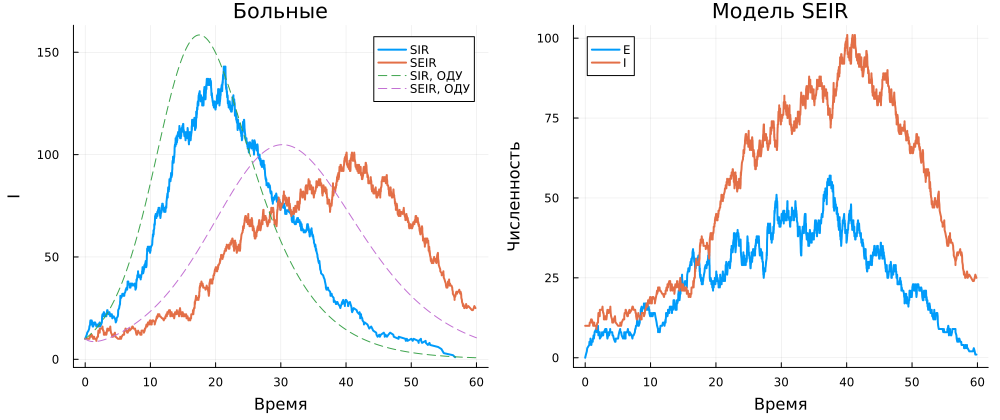

In [7]:
p1 = plot(df_sir.t, df_sir.I, label = "SIR", xlabel = "Время", ylabel = "I", title = "Больные", linewidth = 2)
plot!(p1, df_seir.t, df_seir.I, label = "SEIR", linewidth = 2)
plot!(p1, df_sir_ode.t, df_sir_ode.I, label = "SIR, ОДУ", linestyle = :dash)
plot!(p1, df_seir_ode.t, df_seir_ode.I, label = "SEIR, ОДУ", linestyle = :dash)
p2 = plot(df_seir.t, [df_seir.E df_seir.I], label = ["E" "I"], xlabel = "Время", ylabel = "Численность", title = "Модель SEIR", linewidth = 2)
plt_seir = plot(p1, p2, layout = (1, 2), size = (1000, 420), left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)
savefig(plt_seir, plotsdir("sir_des_seir.png"))
plt_seir